<a href="https://colab.research.google.com/github/kendala545-dot/mis433/blob/main/Aaron_Kendall_text_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Text Analytics

Text analytics turns unstructured language into data that can be counted, compared, visualized, and modeled. Unlike many tabular datasets, text is high-dimensional: a single column of comments, reviews, emails, or news articles can contain thousands of unique words, phrases, spellings, and meanings.

The main challenge is representation. Before we can summarize or model text, we need to decide how to convert language into numeric features while preserving enough meaning for the task. In this notebook, we will practice common steps in that workflow: cleaning and exploring text, converting text to document-term matrices, finding frequent words, measuring word importance with TF-IDF, clustering similar documents, creating word clouds, and estimating sentiment.

# Load and explore data from csv

Source: https://www.kaggle.com/datasets/cloudy17/bob-dylan-songs/

**Context**
This dataset contains songs from years between 1961 to 2020 written by Bob Dylan.

**Content**
There are 4 columns:
* release_year - year when song was released first time,
* album - name of the album where track occurs,
* title - title of the song,
* lyrics - lyrics of the track

In [1]:
import pandas as pd

# load dataset from csv
df = pd.read_csv('https://raw.githubusercontent.com/jiexunli-wwu/mis433/refs/heads/main/data/bob-dylan.csv')
df.head(3) # show the first three rows

,release_year,album,title,lyrics
0,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Hard Times In New York Town,"Come you ladies and you gentlemen, a-listen to..."
1,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Man on the street,"’ll sing you a song, ain’t very long\n\n’Bout ..."
2,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Talkin’ Bear Mountain Picnic Massacre Blues,I saw it advertised one day\n\nBear Mountain p...


In [2]:
# shape of the df: rows and columns
df.shape

(345, 4)

In [3]:
# the data types of each column
df.dtypes

,0
release_year,int64
album,object
title,object
lyrics,object


In [4]:
# Get a summary of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345 entries, 0 to 344
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   release_year  345 non-null    int64 
 1   album         345 non-null    object
 2   title         345 non-null    object
 3   lyrics        345 non-null    object
dtypes: int64(1), object(3)
memory usage: 10.9+ KB


In [5]:
# Count the values of a column
df.release_year.value_counts()

,count
release_year,
1975,30
1965,22
1963,22
1964,21
1970,19
1966,15
1967,13
1981,13
1983,13


In [6]:
df.album.value_counts()

,count
album,
"The Bootleg Series, Vol 1-3: Rare & Unreleased 1961-1991",37
The Basement Tapes,16
The Freewheelin',13
Blonde on Blonde,13
New Morning,12
John Wesley Harding,12
“Love and Theft”,12
Bringing It All Back Home,11
Under the Red Sky,10


In [7]:
# Add a new column
df['decade'] = (df['release_year'] // 10) * 10
df.head()

,release_year,album,title,lyrics,decade
0,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Hard Times In New York Town,"Come you ladies and you gentlemen, a-listen to...",1960
1,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Man on the street,"’ll sing you a song, ain’t very long\n\n’Bout ...",1960
2,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Talkin’ Bear Mountain Picnic Massacre Blues,I saw it advertised one day\n\nBear Mountain p...,1960
3,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Let Me Die in My Footsteps,I will not go down under the ground\n\n’Cause ...,1960
4,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...","Rambling, Gambling Willie",Come around you rovin’ gamblers and a story I ...,1960


In [8]:
# String Operations
# Count the number of words in each song.

df['word_count'] = df['lyrics'].apply(lambda x: len(x.split()))
df.head()

,release_year,album,title,lyrics,decade,word_count
0,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Hard Times In New York Town,"Come you ladies and you gentlemen, a-listen to...",1960,353
1,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Man on the street,"’ll sing you a song, ain’t very long\n\n’Bout ...",1960,158
2,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Talkin’ Bear Mountain Picnic Massacre Blues,I saw it advertised one day\n\nBear Mountain p...,1960,391
3,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Let Me Die in My Footsteps,I will not go down under the ground\n\n’Cause ...,1960,365
4,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...","Rambling, Gambling Willie",Come around you rovin’ gamblers and a story I ...,1960,477


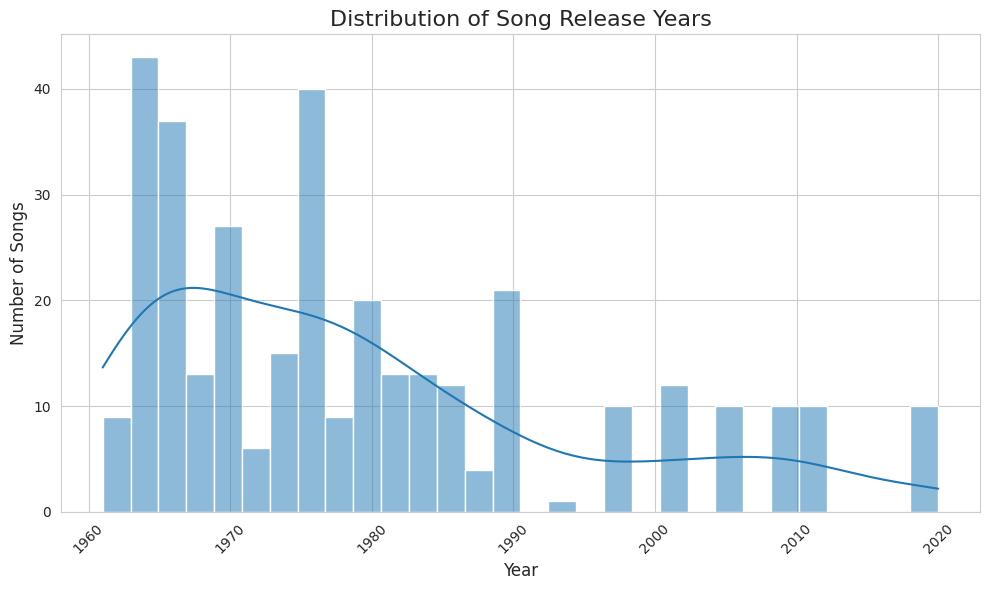

In [9]:
# Visualization

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid') # Set a prettier style

plt.figure(figsize=(10, 6)) # Adjust figure size for better readability
sns.histplot(df['release_year'], bins=30, kde=True) # Use seaborn's histplot with kde for density estimate
plt.title('Distribution of Song Release Years', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Songs', fontsize=12)
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

## scikit-learn

Scikit-learn is one of the most popular Python packages for predictive data analysis. It includes tools for preprocessing text, building feature matrices, clustering documents, and training machine learning models.

https://scikit-learn.org/

If scikit-learn is not installed in your environment, uncomment and run the next cell.

In [10]:
# !pip install scikit-learn

### Vectorization: Converting Text to Numeric Form

Text data must be converted into a numeric form before it can be used with machine learning algorithms. A common technique is `CountVectorizer`, which converts a collection of documents into a document-term matrix. Each row is a document, each column is a token, and each value is the number of times that token appears in that document.

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

# Example using the 'lyrics' column of the Bob Dylan dataset
corpus = df['lyrics'].dropna().tolist()  # Assuming df is your DataFrame and dropping any missing values
vectorizer = CountVectorizer(stop_words='english')  # Remove common 'stop words'
X = vectorizer.fit_transform(corpus)

print(X.shape)  # Shows the shape of the matrix


(345, 7326)


In [12]:
# Accessing the Vocabulary
vocabulary = vectorizer.vocabulary_

# Print the vocabulary dictionary (word: column index)
print(vocabulary)

{'come': 1220, 'ladies': 3508, 'gentlemen': 2630, 'listen': 3691, 'song': 5938, 'sing': 5777, 'right': 5267, 'think': 6491, 'wrong': 7278, 'just': 3423, 'little': 3698, 'glimpse': 2681, 'story': 6172, 'll': 3707, 'tell': 6439, 'bout': 662, 'east': 1989, 'coast': 1182, 'city': 1111, 'know': 3492, 'hard': 2896, 'times': 6558, 'livin': 3704, 'new': 4247, 'york': 7313, 'town': 6627, 'old': 4352, 'friendly': 2531, 'washington': 7031, 'heights': 2981, 'harlem': 2902, 'mighty': 4008, 'people': 4601, 'millin': 4015, 'kick': 3443, 'knock': 3484, 'long': 3731, 'ways': 7056, 'golden': 2706, 'gate': 2605, 'rockefeller': 5321, 'plaza': 4741, 'empire': 2045, 'state': 6108, 'mister': 4055, 'sets': 5607, 'high': 3011, 'bird': 501, 'says': 5488, 'word': 7229, 'country': 1373, 'mornin': 4113, 'tryin': 6734, 'job': 3371, 'work': 7232, 'stand': 6079, 'place': 4706, 'till': 6552, 'feet': 2270, 'begin': 438, 'hurt': 3161, 'got': 2727, 'lot': 3760, 'money': 4084, 'make': 3847, 'merry': 3984, 'nickel': 4256, 

In [13]:
# Size of the vocabulary
len(vocabulary)

7326

In [14]:
# View the first document's feature vector
document_index = 0
feature_vector_sparse = X.getrow(document_index)

# To convert to a dense array
feature_vector_dense = feature_vector_sparse.toarray()

print(feature_vector_dense)

[[0 0 0 ... 0 0 0]]


In [15]:
# To View as a Readable Format

# Get feature names
feature_words = vectorizer.get_feature_names_out()

# Convert the sparse matrix row to a dense array
feature_vector_array = feature_vector_sparse.toarray().flatten()

# Create a dictionary mapping feature names to their values for the document
document_features = {feature_words[i]: int(feature_vector_array[i])
                     for i in range(len(feature_words)) if feature_vector_array[i] != 0}

print(document_features)

{'ay': 1, 'beat': 1, 'begin': 1, 'bird': 1, 'bit': 1, 'bought': 1, 'bout': 1, 'cal': 1, 'caves': 1, 'city': 9, 'cleaner': 1, 'coast': 1, 'come': 2, 'country': 1, 'dirt': 1, 'dream': 1, 'dust': 1, 'east': 1, 'empire': 2, 'feet': 2, 'ferry': 1, 'friendly': 1, 'gate': 1, 'gentlemen': 1, 'glimpse': 1, 'golden': 1, 'got': 2, 'hard': 7, 'harlem': 1, 'heights': 1, 'high': 1, 'hudson': 1, 'hurt': 1, 'island': 1, 'job': 1, 'just': 1, 'kick': 1, 'kind': 1, 'knock': 1, 'know': 1, 'ladies': 1, 'leave': 1, 'listen': 3, 'little': 1, 'livin': 7, 'll': 4, 'long': 1, 'lot': 1, 'make': 1, 'merry': 1, 'mighty': 2, 'millin': 1, 'mines': 1, 'minuet': 1, 'mister': 4, 'money': 1, 'mornin': 1, 'mountain': 1, 'ne': 1, 'new': 10, 'news': 1, 'newsy': 1, 'nickel': 1, 'oklahoma': 1, 'old': 4, 'paid': 1, 'people': 2, 'place': 1, 'plains': 1, 'plaza': 1, 'right': 2, 'rockefeller': 2, 'rocky': 1, 'sailin': 1, 'says': 1, 'sell': 1, 'sets': 1, 'sing': 1, 'smog': 1, 'song': 2, 'spread': 1, 'stand': 1, 'standin': 1, 'sta

In [16]:
# Getting the Most Frequent Words

import numpy as np

# Sum up the counts of each word across all documents
word_counts = np.sum(X.toarray(), axis=0)  # X is the result of vectorizer.fit_transform(corpus)

# Map from feature index to word
feature_words = vectorizer.get_feature_names_out()

# Combine counts and words into a dictionary, ensuring counts are Python integers
word_count_dict = {word: int(count) for word, count in zip(feature_words, word_counts)}

# Sort the dictionary by counts in descending order to get the most frequent words
sorted_word_count = sorted(word_count_dict.items(), key=lambda x: x[1], reverse=True)

# Print the top N most frequent words
top_n_words = 20  # You can adjust N as needed
print(sorted_word_count[:top_n_words])

[('don', 553), ('like', 496), ('just', 477), ('got', 465), ('ll', 451), ('know', 418), ('love', 301), ('gonna', 296), ('man', 287), ('time', 273), ('ve', 273), ('ain', 271), ('said', 265), ('come', 253), ('say', 252), ('oh', 241), ('tell', 219), ('baby', 207), ('way', 195), ('day', 192)]


/tmp/ipykernel_776/531371955.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Word', y='Count', data=most_frequent_words_df, palette='viridis')


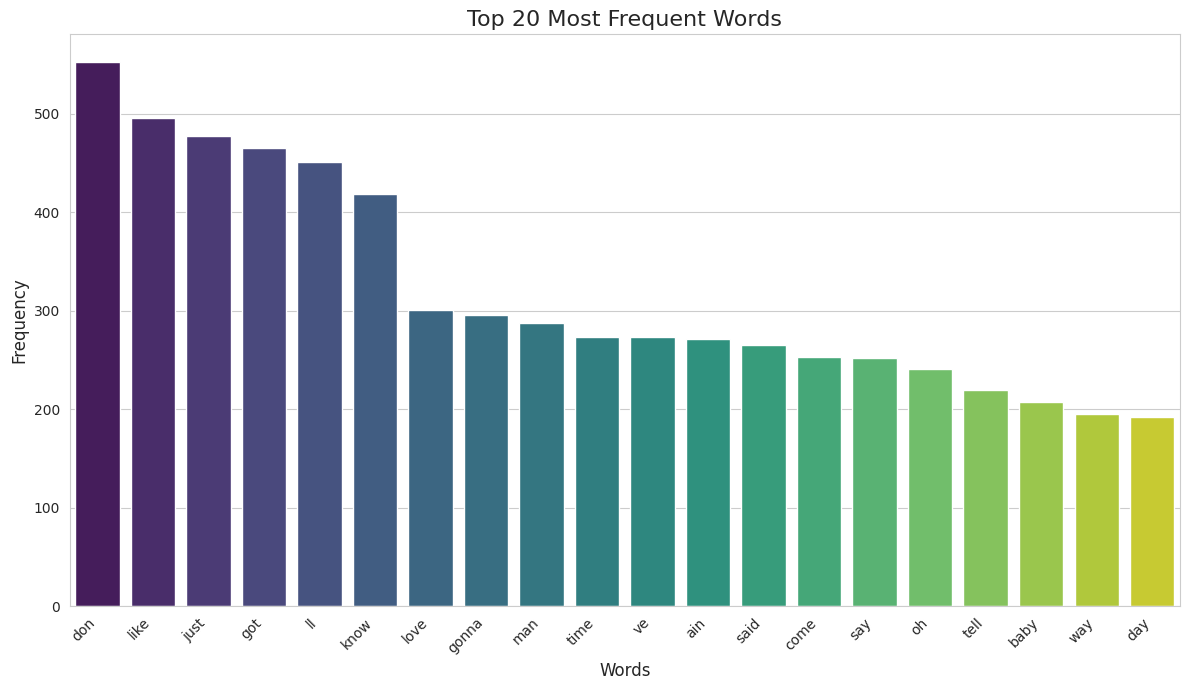

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract words and counts from the sorted_word_count list
words = [item[0] for item in sorted_word_count[:top_n_words]]
counts = [item[1] for item in sorted_word_count[:top_n_words]]

# Create a DataFrame for easier plotting with seaborn
most_frequent_words_df = pd.DataFrame({'Word': words, 'Count': counts})

# Create the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Word', y='Count', data=most_frequent_words_df, palette='viridis')
plt.title('Top 20 Most Frequent Words', fontsize=16)
plt.xlabel('Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

### TF-IDF: Weighing Word Importance

TF-IDF stands for term frequency-inverse document frequency. It gives higher scores to words that appear often in a particular document but not too often across the entire collection. This helps reduce the influence of common words and highlight words that are more distinctive for a song.

In practice, TF-IDF is often more useful than raw word counts for comparing documents because it balances local importance with overall rarity.

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(stop_words='english')
X_tfidf = tfidf_vectorizer.fit_transform(corpus)

print(X_tfidf.shape)


(345, 7326)


### Clustering: Grouping Similar Songs

With the numeric representations, you can now perform clustering to group similar songs.

**K-means** is a popular algorithm that can partition a set of data points into K groups, where K is predefined.

In [19]:
from sklearn.cluster import KMeans

# Using TF-IDF vectors for clustering
kmeans = KMeans(n_clusters=5, random_state=0)  # Assuming we want to cluster into 5 groups
kmeans.fit(X_tfidf)

# Print cluster labels for each song
print(kmeans.labels_)

# Count the number of songs in each cluster (from KMeans)
cluster_counts = np.bincount(kmeans.labels_)

print("KMeans Cluster Sizes:")
for i, count in enumerate(cluster_counts):
    print(f"Cluster {i}: {count} songs")

[3 4 3 3 4 1 3 3 3 4 3 2 2 3 1 3 3 3 4 3 1 3 3 1 1 4 4 4 4 3 4 3 3 4 0 3 4
 1 1 0 1 3 3 3 3 1 0 3 1 4 3 3 1 3 2 1 3 3 3 3 3 3 4 0 1 3 4 1 1 1 3 1 4 3
 4 1 3 2 3 4 3 1 3 1 1 3 0 2 3 4 1 4 3 2 4 4 3 1 1 2 4 3 3 1 1 2 0 3 3 3 3
 4 4 0 4 4 3 3 3 2 0 3 0 4 4 0 1 1 2 3 3 0 3 3 3 3 1 3 0 3 1 1 3 2 3 3 1 2
 1 2 1 1 3 0 4 2 4 4 1 0 3 3 3 1 1 3 0 3 0 4 1 4 4 1 3 3 3 4 1 3 4 4 0 2 4
 3 4 2 4 0 1 3 3 1 4 1 3 1 3 1 3 1 1 0 4 3 1 1 3 1 4 1 3 2 1 0 2 3 1 1 1 0
 3 3 4 1 3 3 0 3 3 3 0 2 3 2 1 3 1 3 1 1 4 3 4 3 1 1 1 3 2 3 3 3 0 3 0 4 1
 3 3 3 1 4 1 1 1 3 4 4 3 3 4 3 3 3 1 3 3 4 3 0 4 3 3 3 3 3 2 3 3 2 3 3 3 3
 3 3 3 4 3 1 3 3 3 3 3 3 1 3 1 1 3 1 3 1 2 1 3 3 3 3 1 1 3 3 3 3 3 2 3 4 3
 1 1 1 4 2 3 3 3 3 3 2 3]
KMeans Cluster Sizes:
Cluster 0: 26 songs
Cluster 1: 82 songs
Cluster 2: 27 songs
Cluster 3: 154 songs
Cluster 4: 56 songs


**Hierarchical Clustering** is a different algorithm that agglomeratively groups similar objects into clusters, eventually forming a tree (hierarchy) of clusters.

Visualizing Clusters as a Tree (Dendrogram using Hierarchical Clustering):


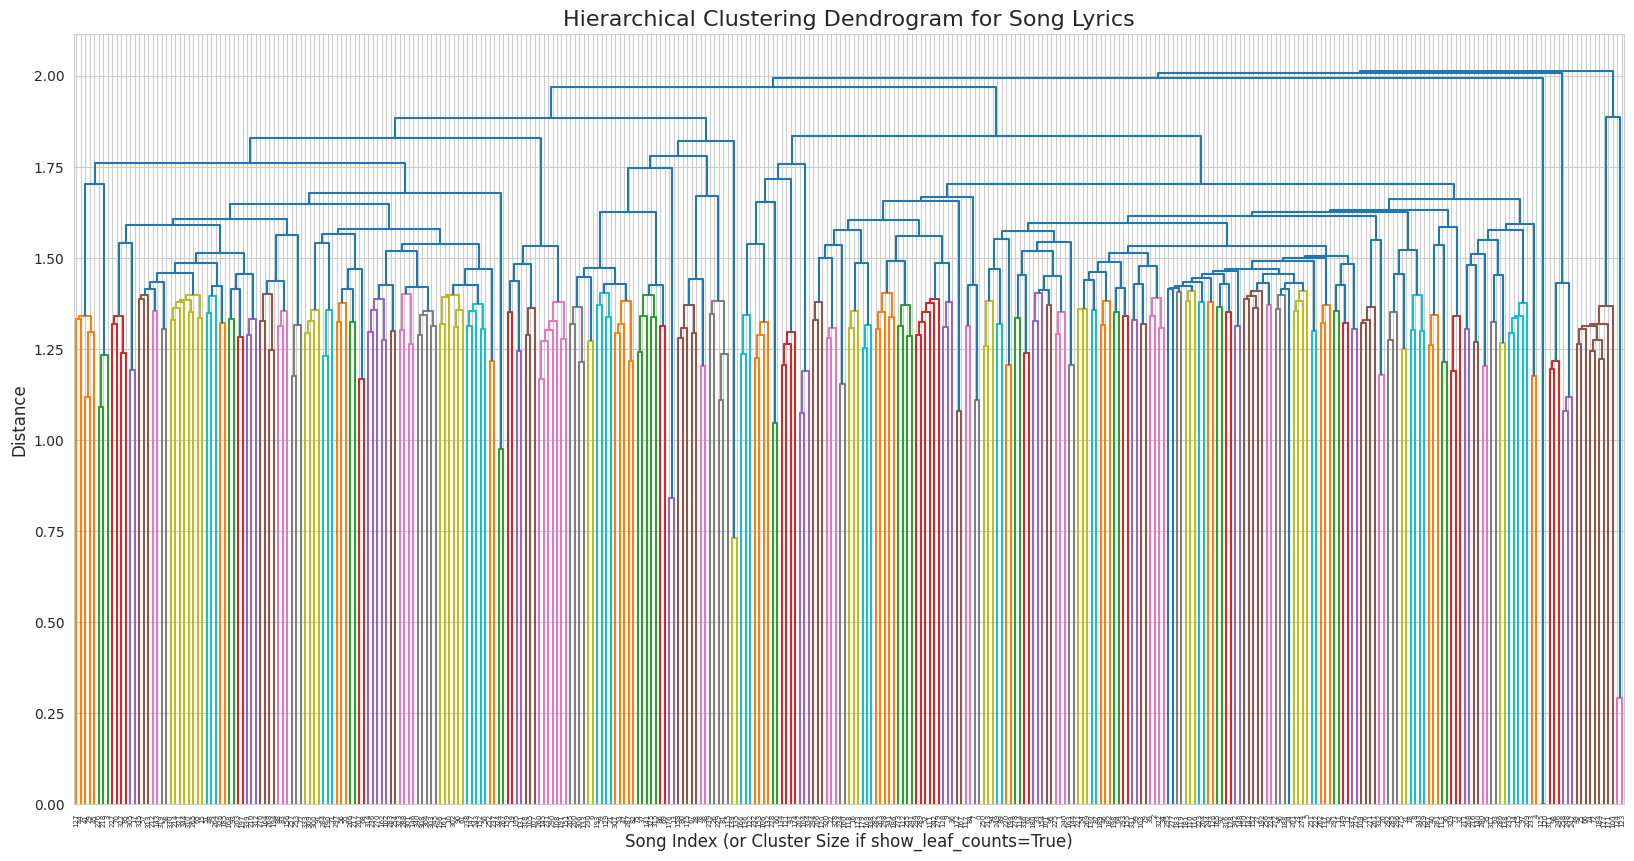

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

print("Visualizing Clusters as a Tree (Dendrogram using Hierarchical Clustering):")

# Perform hierarchical clustering on the TF-IDF vectors
# 'ward' linkage minimizes the variance of the clusters being merged.
# You can choose other methods like 'complete', 'average', 'single'.
linked = linkage(X_tfidf.toarray(), 'ward')

# Plot the dendrogram
plt.figure(figsize=(20, 10))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram for Song Lyrics', fontsize=16)
plt.xlabel('Song Index (or Cluster Size if show_leaf_counts=True)', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.show()

### Create a Word Cloud

A word cloud is a quick visual summary of common words. It is easy to read, but it should be treated as exploratory rather than analytical because it does not show exact counts or account for context.

In [21]:
# Install wordcloud package
#!pip install --upgrade wordcloud

In [22]:
# You may need to run this too.
#!pip install --upgrade Pillow

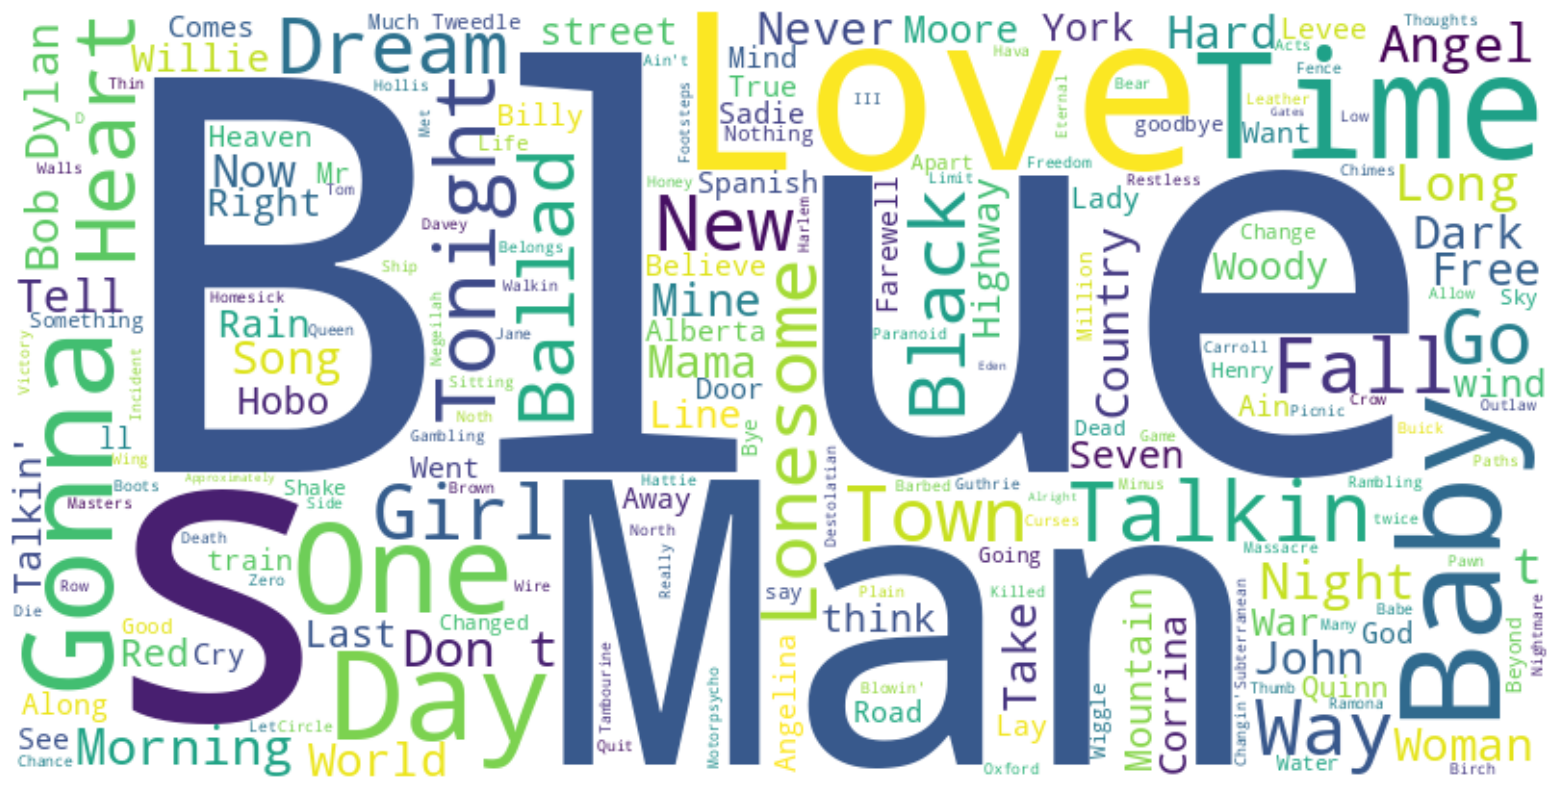

In [23]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all the text in the 'title' column into a single string
all_titles_text = " ".join(title for title in df['title'])

# Generate a word cloud image
wordcloud = WordCloud(background_color='white', width=800, height=400).generate(all_titles_text)

# Display the generated image
plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()


### Sentiment Analysis with a Pre-trained Model

For a simple sentiment analysis, you can use a pre-trained model from libraries such as TextBlob to estimate the sentiment score expressed in text.

TextBlob: https://textblob.readthedocs.io/en/dev/

In [24]:
# Install TextBlob
!pip install textblob

In [25]:
# This example uses TextBlob for sentiment analysis
from textblob import TextBlob

# Sample usage with the first five song's lyrics
for i in range(5):
    title = df['title'].iloc[i]
    lyrics = df['lyrics'].iloc[i]
    blob = TextBlob(lyrics)
    score = blob.sentiment.polarity
    print(f"{title}\t{lyrics[:25]}...\t{score}")

Hard Times In New York Town	Come you ladies and you g...	0.011896504729838058
Man on the street	’ll sing you a song, ain’...	-0.0692063492063492
Talkin’ Bear Mountain Picnic Massacre Blues	I saw it advertised one d...	0.14592111592111595
Let Me Die in My Footsteps	I will not go down under ...	-0.04433742183742184
Rambling, Gambling Willie	Come around you rovin’ ga...	-0.014664989664989669


## Exercises

Try these exercises to practice adapting the workflow above. Start by writing the code yourself, then compare your result with a partner or instructor.

In [26]:
# Exercise 1: Find the top 10 frequent words in Dylan's songs for each decade.
# Hint: loop through text_df.groupby('decade'), then fit a CountVectorizer to each decade's lyrics.

import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

top_n_words = 10

# Group the DataFrame by 'decade'
for decade, decade_df in df.groupby('decade'):
    print(f"\n--- Decade: {decade}s ---")

    # Extract lyrics for the current decade, dropping any missing values
    decade_corpus = decade_df['lyrics'].dropna().tolist()

    if not decade_corpus:
        print("No lyrics found for this decade.")
        continue

    # Initialize a new CountVectorizer for each decade
    vectorizer = CountVectorizer(stop_words='english')
    X_decade = vectorizer.fit_transform(decade_corpus)

    # Sum up the counts of each word across all documents in the decade
    word_counts_decade = np.sum(X_decade.toarray(), axis=0)

    # Map from feature index to word for the current decade
    feature_words_decade = vectorizer.get_feature_names_out()

    # Combine counts and words into a dictionary
    word_count_dict_decade = {word: int(count) for word, count in zip(feature_words_decade, word_counts_decade)}

    # Sort the dictionary by counts in descending order
    sorted_word_count_decade = sorted(word_count_dict_decade.items(), key=lambda x: x[1], reverse=True)

    # Print the top N most frequent words for the current decade
    print(f"Top {top_n_words} most frequent words:")
    for word, count in sorted_word_count_decade[:top_n_words]:
        print(f"- {word}: {count}")


--- Decade: 1960s ---
Top 10 most frequent words:
- just: 182
- don: 152
- like: 142
- ll: 138
- got: 135
- ain: 127
- know: 126
- said: 103
- come: 88
- man: 84

--- Decade: 1970s ---
Top 10 most frequent words:
- like: 146
- don: 140
- gonna: 125
- just: 113
- said: 98
- know: 94
- ll: 91
- oh: 90
- time: 89
- got: 85

--- Decade: 1980s ---
Top 10 most frequent words:
- don: 135
- got: 110
- know: 105
- like: 97
- just: 96
- love: 87
- man: 67
- time: 64
- ll: 60
- baby: 59

--- Decade: 1990s ---
Top 10 most frequent words:
- wiggle: 55
- like: 42
- don: 36
- got: 31
- god: 28
- know: 27
- til: 27
- just: 26
- knows: 22
- gonna: 21

--- Decade: 2000s ---
Top 10 most frequent words:
- got: 77
- don: 57
- ll: 52
- gonna: 51
- just: 44
- know: 44
- day: 41
- say: 41
- ain: 39
- good: 39

--- Decade: 2010s ---
Top 10 most frequent words:
- ll: 44
- long: 32
- blowin: 22
- work: 22
- way: 20
- like: 18
- day: 16
- heart: 16
- town: 14
- light: 13

--- Decade: 2020s ---
Top 10 most freque

/tmp/ipykernel_776/1376998154.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='decade', y='sentiment_polarity', data=df, palette='viridis')


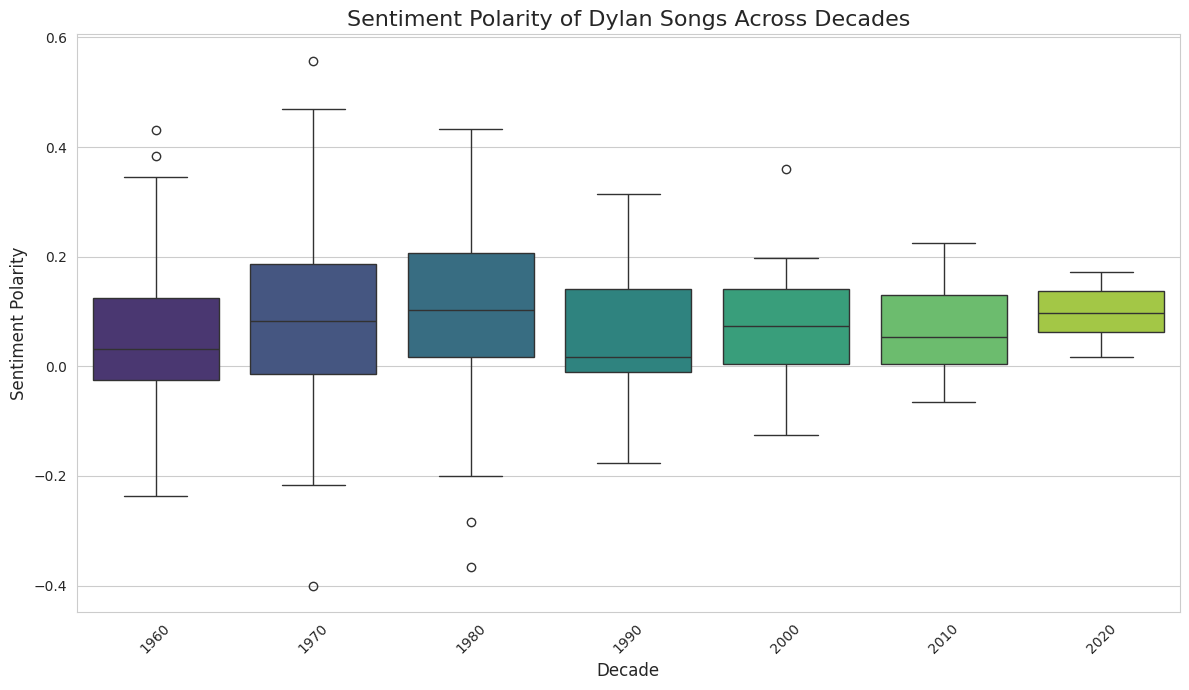

In [27]:
# Exercise 2: Create a boxplot showing sentiment scores across decades.
# Hint: use x='decade' and y='sentiment_polarity' with sns.boxplot().

from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate sentiment polarity for each song and store it in a new column
df['sentiment_polarity'] = df['lyrics'].apply(lambda x: TextBlob(x).sentiment.polarity)

# Create the boxplot
plt.figure(figsize=(12, 7))
sns.boxplot(x='decade', y='sentiment_polarity', data=df, palette='viridis')
plt.title('Sentiment Polarity of Dylan Songs Across Decades', fontsize=16)
plt.xlabel('Decade', fontsize=12)
plt.ylabel('Sentiment Polarity', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Working with Text Data from an API

Many API responses contain text data. For instance, the [NewsAPI](https://newsapi.org/) searches articles and breaking-news headlines from news sources and blogs across the web.

In this section, we will search recent news articles and convert the results into a DataFrame for text analysis.

To use the NewsAPI, you'll need an API key. It's recommended to store your API key securely in Colab's secrets manager under the "🔑" icon in the left panel. Name the secret `NEWS_API_KEY`.

In [28]:
from google.colab import userdata

NEWS_API_KEY = userdata.get('NEWS_API_KEY')
print(f"API Key: {NEWS_API_KEY}")

API Key: 0a0e0c6dfbac43efade79d27c40b079c


In [29]:
import datetime

# Get today's date
today = datetime.date.today()

# Calculate the date three days ago
three_days_ago = today - datetime.timedelta(days=3)

# Format the date for the API request (YYYY-MM-DD)
from_param = three_days_ago.strftime('%Y-%m-%d')

print(f"Fetching news from: {from_param} to {today.strftime('%Y-%m-%d')}")

Fetching news from: 2026-05-29 to 2026-06-01


In [31]:
import requests
import pandas as pd # Import pandas for DataFrame

query = input("Please enter your search query for news articles: ")
print(f"Searching for articles related to: {query}")

# NewsAPI endpoint for all articles
url = 'https://newsapi.org/v2/everything'

# Parameters for the request
params = {
    'pageSize': 100,    # Max number of articles to retrieve per request for 'everything' endpoint
    'apiKey': NEWS_API_KEY,
    'q': query, # The search query
    'from': from_param, # Start date for the search (already calculated)
    'to': today.strftime('%Y-%m-%d'), # End date for the search (today)
    'language': 'en' # Filter for English language articles
}

try:
    response = requests.get(url, params=params)
    response.raise_for_status() # Raise an exception for HTTP errors
    data = response.json()

    print("Successfully fetched news articles.")

    articles_data = []
    for article in data['articles']:
        source_name = article.get('source', {}).get('name', 'N/A')
        articles_data.append({
            'title': article.get('title'),
            'author': article.get('author'),
            'source': source_name,
            'description': article.get('description'),
            'date': article.get('publishedAt')
        })

    news_df = pd.DataFrame(articles_data)

    print(f"Total articles retrieved and saved to DataFrame: {len(news_df)}")
    print(f"Total results matching query (available from API): {data['totalResults']}")
    display(news_df.head())

except requests.exceptions.RequestException as e:
    print(f"Error fetching news: {e}")
    if response.status_code == 401:
        print("Unauthorized: Check your API key.")
    elif response.status_code == 429:
        print("Too Many Requests: You may have hit your API rate limit.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Please enter your search query for news articles: SpaceX
Searching for articles related to: SpaceX
Successfully fetched news articles.
Total articles retrieved and saved to DataFrame: 93
Total results matching query (available from API): 213


,title,author,source,description,date
0,SpaceX gets $4 billion contract to build missi...,Emma Roth,The Verge,The Pentagon awarded SpaceX a $4.16 billion co...,2026-05-29T21:48:52Z
1,Top analyst has harsh words for SpaceX debut: ...,Shawn Tully,Yahoo Entertainment,Research firm CEO David Trainer says SpaceX's ...,2026-05-29T07:00:00Z
2,Blue Origin Rocket Exploded Thursday Night Dur...,EditorDavid,Slashdot.org,Spaceflight Now shared their video of the expl...,2026-05-29T18:28:00Z
3,"After Blue Origin rocket explosion, NASA’s ent...",Jason Ma,Yahoo Entertainment,"""Blue Origin’s inability to launch Blue Moon a...",2026-05-30T19:42:29Z
4,"Blue Origin rocket explodes during test, setba...",Reuters,Yahoo Entertainment,May 28 (Reuters) - A Blue Origin New Glenn roc...,2026-05-29T02:45:59Z


### Analyze the Text in the News Articles

What questions can we ask about this dataset?

- Which words appear most often in article titles or descriptions?
- Do different sources use different language for the same topic?
- How does sentiment vary across articles or sources?
- Are there clusters of articles that focus on different subtopics?

Top 20 most frequent words in news article titles and descriptions:
- spacex: 107
- ipo: 51
- blue: 49
- rocket: 48
- origin: 47
- new: 31
- space: 30
- launch: 24
- valuation: 24
- glenn: 23
- ai: 21
- explosion: 16
- test: 16
- crypto: 15
- musk: 14
- bezos: 13
- billion: 13
- company: 13
- contract: 13
- explodes: 13


/tmp/ipykernel_776/817235159.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Word', y='Count', data=most_frequent_words_news_df, palette='magma')


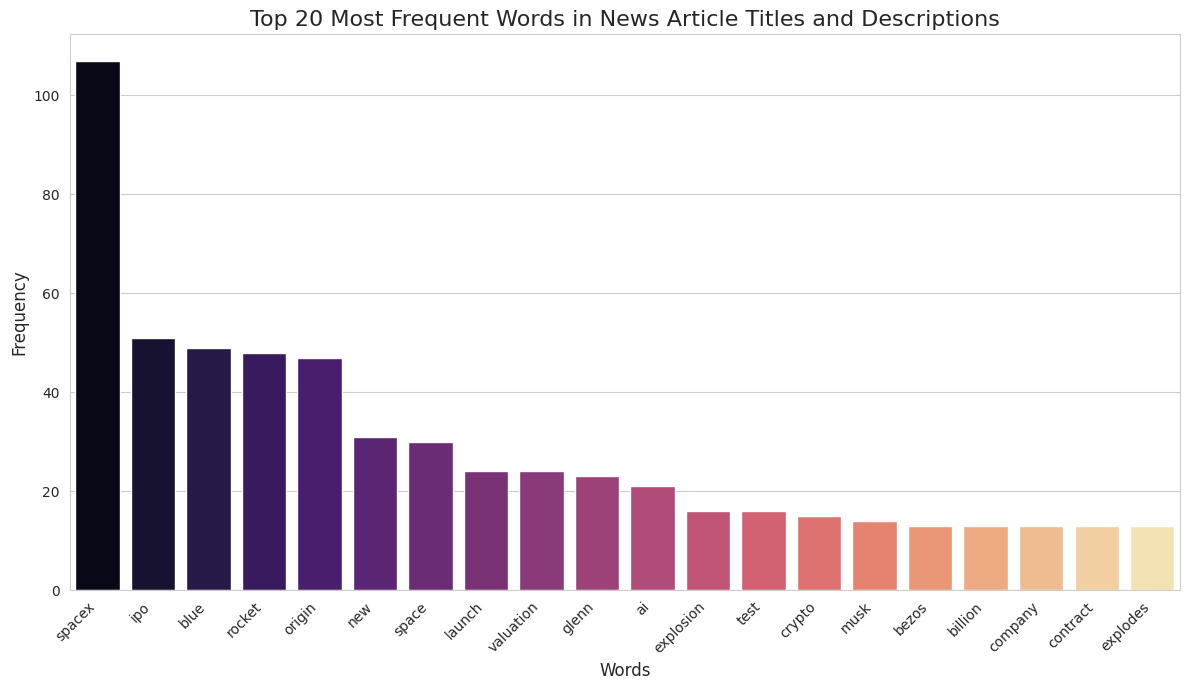

In [32]:
# Which words appear most often in article titles or descriptions?

import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Combine title and description into a single text field for each article
# Fill any NaN values with an empty string before combining
news_df['combined_text'] = news_df['title'].fillna('') + ' ' + news_df['description'].fillna('')

# Create a corpus from the combined text
news_corpus = news_df['combined_text'].tolist()

# Initialize CountVectorizer to remove common English stop words
vectorizer_news = CountVectorizer(stop_words='english')

# Fit and transform the corpus
X_news = vectorizer_news.fit_transform(news_corpus)

# Sum up the counts of each word across all documents
word_counts_news = np.sum(X_news.toarray(), axis=0)

# Get feature names (words)
feature_words_news = vectorizer_news.get_feature_names_out()

# Combine counts and words into a dictionary
word_count_dict_news = {word: int(count) for word, count in zip(feature_words_news, word_counts_news)}

# Sort the dictionary by counts in descending order
sorted_word_count_news = sorted(word_count_dict_news.items(), key=lambda x: x[1], reverse=True)

# Print the top N most frequent words
top_n_words_news = 20  # You can adjust N as needed
print(f"Top {top_n_words_news} most frequent words in news article titles and descriptions:")
for word, count in sorted_word_count_news[:top_n_words_news]:
    print(f"- {word}: {count}")

# Optionally, visualize the top words
words_news = [item[0] for item in sorted_word_count_news[:top_n_words_news]]
counts_news = [item[1] for item in sorted_word_count_news[:top_n_words_news]]

most_frequent_words_news_df = pd.DataFrame({'Word': words_news, 'Count': counts_news})

plt.figure(figsize=(12, 7))
sns.barplot(x='Word', y='Count', data=most_frequent_words_news_df, palette='magma')
plt.title(f'Top {top_n_words_news} Most Frequent Words in News Article Titles and Descriptions', fontsize=16)
plt.xlabel('Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Sentiment polarity calculated for each article:


,source,title,sentiment_polarity
0,The Verge,SpaceX gets $4 billion contract to build missi...,0.200000
1,Yahoo Entertainment,Top analyst has harsh words for SpaceX debut: ...,0.025000
2,Slashdot.org,Blue Origin Rocket Exploded Thursday Night Dur...,0.000000
3,Yahoo Entertainment,"After Blue Origin rocket explosion, NASA’s ent...",0.000000
4,Yahoo Entertainment,"Blue Origin rocket explodes during test, setba...",0.045455



Sentiment statistics by source:


,mean,median,std,count
source,,,,
Digitimes,0.375000,0.375000,NaN,1
Etf.com,0.375000,0.375000,NaN,1
24/7 Wall St.,0.333333,0.333333,NaN,1
CoinDesk,0.250000,0.250000,NaN,1
Alltoc.com,0.217083,0.217083,0.191508,2
New York Post,0.216667,0.216667,NaN,1
TheStreet,0.213333,0.140000,0.257941,3
Gizmodo.com,0.200000,0.200000,0.282843,2
The Verge,0.200000,0.200000,NaN,1


/tmp/ipykernel_776/160503050.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='source', y='sentiment_polarity', data=news_df, palette='coolwarm')


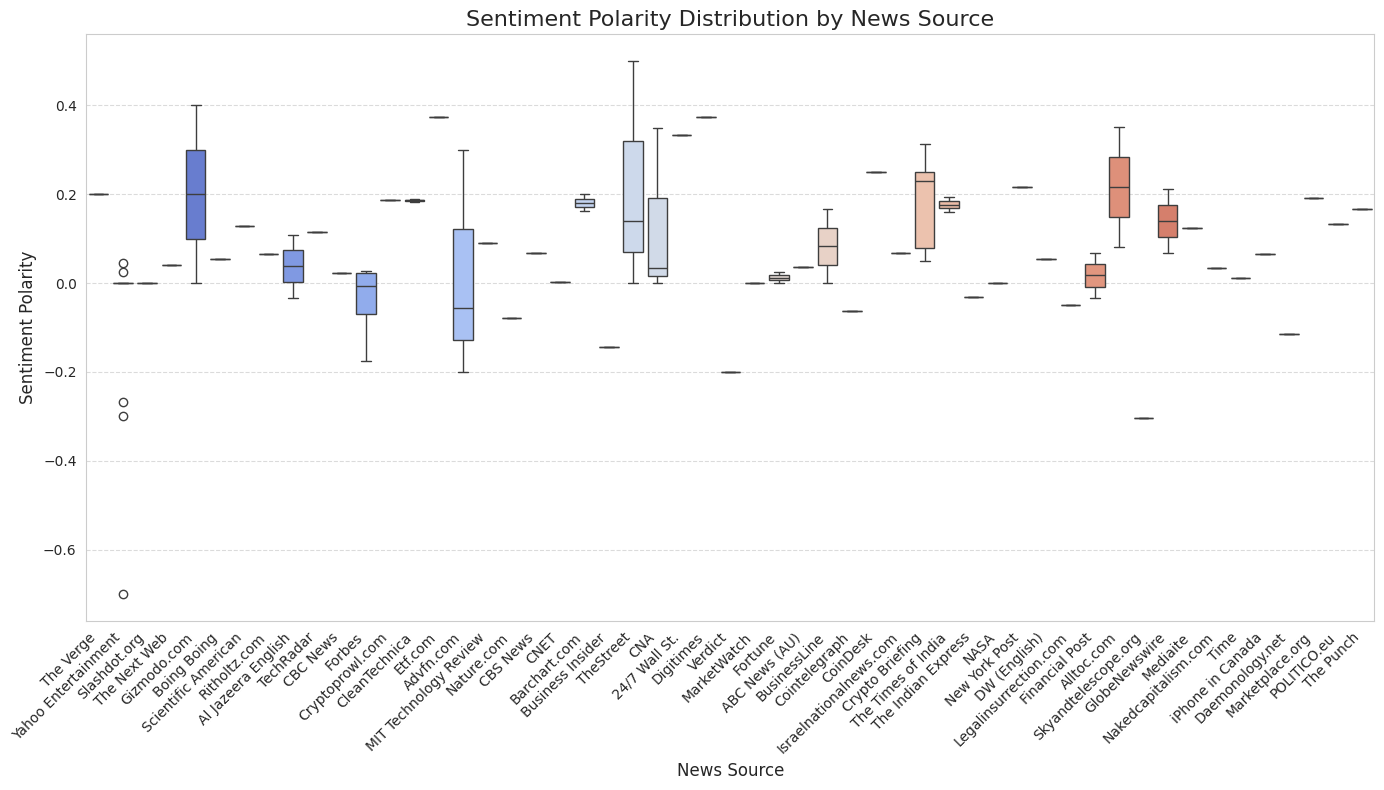


Top and bottom sentiment articles for sources with at least 5 articles:

--- Source: Crypto Briefing (Mean Sentiment: 0.18) ---
Top 3 most positive articles:
  - 'SpaceX secures $4.16B contract from US Space Force for airborne threat tracking' (Polarity: 0.31)
  - 'SpaceX wins $4.16B contract to build US Golden Dome tracking satellites' (Polarity: 0.26)
  - 'SpaceX targets $1.8T valuation for 2026 IPO debut' (Polarity: 0.25)
Top 3 most negative articles:
  - 'SpaceX eyes $1.7T IPO valuation, boosting market cap expectations' (Polarity: 0.08)
  - 'SpaceX IPO frenzy drives $18M in daily volume on perpetual futures' (Polarity: 0.06)
  - 'OpenAI, SpaceX funding fuels bets on next-wave Asian AI winners' (Polarity: 0.05)

--- Source: Yahoo Entertainment (Mean Sentiment: -0.08) ---
Top 3 most positive articles:
  - 'Blue Origin rocket explodes during test, setback for bid to catch SpaceX' (Polarity: 0.05)
  - 'Top analyst has harsh words for SpaceX debut: ‘We recommend that investors avoid t

In [33]:
# How does sentiment vary across articles or sources?

from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'combined_text' column exists, created in a previous step.
# If not, create it again for robustness.
if 'combined_text' not in news_df.columns:
    news_df['combined_text'] = news_df['title'].fillna('') + ' ' + news_df['description'].fillna('')

# Calculate sentiment polarity for each article
# textblob.sentiment.polarity returns a float within the range [-1.0, 1.0]
# where -1.0 is negative and 1.0 is positive.
news_df['sentiment_polarity'] = news_df['combined_text'].apply(lambda x: TextBlob(x).sentiment.polarity)

print("Sentiment polarity calculated for each article:")
display(news_df[['source', 'title', 'sentiment_polarity']].head())

# Group by source and calculate descriptive statistics for sentiment polarity
sentiment_by_source = news_df.groupby('source')['sentiment_polarity'].agg(['mean', 'median', 'std', 'count']).sort_values(by='mean', ascending=False)
print("\nSentiment statistics by source:")
display(sentiment_by_source)

# Visualize sentiment distribution by source
plt.figure(figsize=(14, 8))
sns.boxplot(x='source', y='sentiment_polarity', data=news_df, palette='coolwarm')
plt.title('Sentiment Polarity Distribution by News Source', fontsize=16)
plt.xlabel('News Source', fontsize=12)
plt.ylabel('Sentiment Polarity', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Optionally, for sources with enough articles, show the top/bottom sentiment articles
# Get sources with at least 5 articles for a more meaningful analysis
min_articles_for_detail = 5
relevant_sources = sentiment_by_source[sentiment_by_source['count'] >= min_articles_for_detail].index

if not relevant_sources.empty:
    print(f"\nTop and bottom sentiment articles for sources with at least {min_articles_for_detail} articles:")
    for source in relevant_sources:
        source_df = news_df[news_df['source'] == source].sort_values(by='sentiment_polarity', ascending=False)
        print(f"\n--- Source: {source} (Mean Sentiment: {sentiment_by_source.loc[source]['mean']:.2f}) ---")
        print("Top 3 most positive articles:")
        for i, row in source_df.head(3).iterrows():
            print(f"  - '{row['title']}' (Polarity: {row['sentiment_polarity']:.2f})")
        print("Top 3 most negative articles:")
        for i, row in source_df.tail(3).iterrows():
            print(f"  - '{row['title']}' (Polarity: {row['sentiment_polarity']:.2f})")


In [34]:
# Do different sources use different language for the same topic?

from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np

# Ensure 'combined_text' column exists
if 'combined_text' not in news_df.columns:
    news_df['combined_text'] = news_df['title'].fillna('') + ' ' + news_df['description'].fillna('')

# Filter out sources with very few articles, as TF-IDF might not be meaningful
# for sources with only one or two articles.
min_articles_for_tfidf = 3
filtered_news_df = news_df.groupby('source').filter(lambda x: len(x) >= min_articles_for_tfidf)

print(f"Analyzing language for sources with at least {min_articles_for_tfidf} articles:")

if filtered_news_df.empty:
    print("No sources meet the minimum article threshold for TF-IDF analysis.")
else:
    for source_name, group_df in filtered_news_df.groupby('source'):
        print(f"\n--- Source: {source_name} ({len(group_df)} articles) ---")

        # Create a corpus for the current source
        source_corpus = group_df['combined_text'].tolist()

        # Initialize TF-IDF Vectorizer. Use min_df to ignore terms that appear
        # in too few documents within this source, and max_df to ignore terms
        # that appear in too many (i.e., are too common within the source).
        tfidf_vectorizer_source = TfidfVectorizer(stop_words='english', min_df=0.1, max_df=0.9)

        # Fit and transform the corpus for the current source
        try:
            X_tfidf_source = tfidf_vectorizer_source.fit_transform(source_corpus)
        except ValueError as e:
            print(f"  Could not perform TF-IDF for {source_name}: {e}")
            continue

        # Get feature names (words)
        feature_words_source = tfidf_vectorizer_source.get_feature_names_out()

        # Calculate the average TF-IDF score for each word in this source
        avg_tfidf_scores = X_tfidf_source.mean(axis=0)

        # Create a dictionary of word to average TF-IDF score
        tfidf_scores_dict = {word: float(avg_tfidf_scores[0, idx])
                             for idx, word in enumerate(feature_words_source)}

        # Sort words by their TF-IDF scores in descending order
        sorted_tfidf_words = sorted(tfidf_scores_dict.items(), key=lambda x: x[1], reverse=True)

        # Print the top N most distinctive words for this source
        top_n_tfidf_words = 10
        print(f"  Top {top_n_tfidf_words} most distinctive words (TF-IDF scores):")
        for word, score in sorted_tfidf_words[:top_n_tfidf_words]:
            print(f"  - {word}: {score:.4f}")


Analyzing language for sources with at least 3 articles:

--- Source: Advfn.com (3 articles) ---
  Top 10 most distinctive words (TF-IDF scores):
  - tesla: 0.1385
  - ceasefire: 0.1134
  - futures: 0.1134
  - investors: 0.1134
  - spacex: 0.1086
  - nasdaq: 0.0958
  - 2026: 0.0735
  - ai: 0.0735
  - anthropic: 0.0735
  - blockbuster: 0.0735

--- Source: CNA (3 articles) ---
  Top 10 most distinctive words (TF-IDF scores):
  - space: 0.2872
  - 16: 0.1914
  - billion: 0.1914
  - force: 0.1914
  - deal: 0.1500
  - target: 0.1372
  - launch: 0.1341
  - designed: 0.1090
  - 29: 0.0957
  - airborne: 0.0957

--- Source: Crypto Briefing (8 articles) ---
  Top 10 most distinctive words (TF-IDF scores):
  - ipo: 0.1816
  - valuation: 0.1091
  - contract: 0.0955
  - space: 0.0934
  - 2026: 0.0798
  - 8t: 0.0798
  - debut: 0.0798
  - targets: 0.0798
  - 16b: 0.0794
  - force: 0.0678

--- Source: Forbes (4 articles) ---
  Top 10 most distinctive words (TF-IDF scores):
  - blue: 0.1611
  - origin: